# Artificial Neural Networks

**Name:** Abdulaziz Aloufi  
**Student ID:** C00266252  
**Module:** Data Science & Machine Learning 2  

## Overview
This notebook implements an Artificial Neural Network (ANN) using a dataset about AI and student performance.

The aim is to predict the student's **performance category** (`Low`, `Medium`, `High`) based on AI usage and academic-related features.

In this notebook I will:
- load and inspect the dataset
- prepare the data
- encode categorical columns
- scale the features
- train a neural network classifier
- evaluate the results
- compare different hidden layer settings

In [1]:
# =====================================================
# Artificial Neural Networks
# Name: Abdulaziz Aloufi
# Student ID: C00266252
# =====================================================

# importing the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# nicer plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## 1. Load the dataset

For this notebook I am using the same dataset about AI and student performance.

I chose to reuse it here because:
- it allows comparison between algorithms
- it has a clear target column called `performance_category`

In [2]:
# loading the dataset
df = pd.read_csv("../data/ai_impact_student_performance_dataset.csv")

# first look at the dataset
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [3]:
# filling missing values in categorical columns
df["ai_tools_used"] = df["ai_tools_used"].fillna("Unknown")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("Unknown")

# checking again
print(df.isnull().sum())
print("\nTotal missing values after fixing:", df.isnull().sum().sum())

student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

Total missing values aft

In [4]:
# separating features and target
X = df.drop(columns=["student_id", "final_score", "passed", "performance_category"])
y = df["performance_category"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8000, 22)
Target shape: (8000,)


performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64


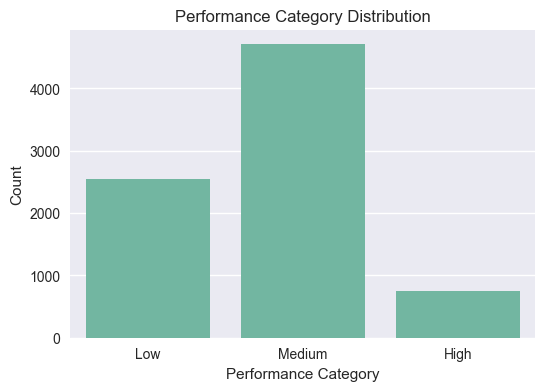

In [5]:
# checking class distribution
print(y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Count")
plt.show()

In [6]:
# making a copy so I keep the original safe
X_encoded = X.copy()

# finding categorical columns
cat_cols = X_encoded.select_dtypes(include=["object"]).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']


In [7]:
# encoding the categorical columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# encoding the target labels too
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# quick check
X_encoded.head()

,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
0,20,0,3,2.5,1,170,5,2,10,29,...,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6
1,17,1,2,3.4,1,123,5,4,4,14,...,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6
2,24,1,5,0.8,0,35,3,1,8,82,...,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3
3,21,0,2,4.4,0,45,1,4,3,74,...,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2
4,18,2,5,3.5,1,21,1,0,2,83,...,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2


In [8]:
# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (6400, 22)
Test shape: (1600, 22)


In [9]:
# scaling the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (6400, 22)
Scaled test shape: (1600, 22)


In [10]:
# training the first neural network model
nn_model = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

# predictions
y_pred = nn_model.predict(X_test_scaled)

# accuracy
print("Accuracy (hidden_layer_sizes=(50,)):", accuracy_score(y_test, y_pred))

Accuracy (hidden_layer_sizes=(50,)): 0.816875


C:\Users\mralo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
# classification report
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

        High       0.68      0.66      0.67       151
         Low       0.80      0.82      0.81       508
      Medium       0.85      0.84      0.84       941

    accuracy                           0.82      1600
   macro avg       0.78      0.77      0.77      1600
weighted avg       0.82      0.82      0.82      1600



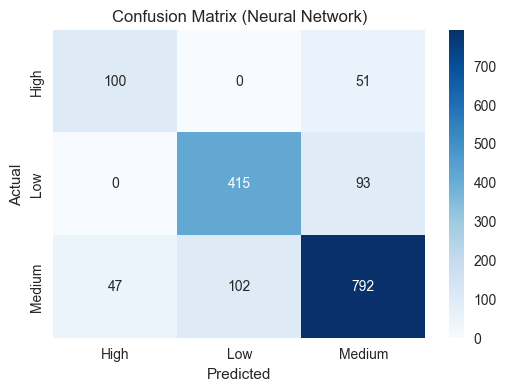

In [12]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix (Neural Network)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# comparing different hidden layer settings
architectures = [
    (20,),
    (50,),
    (100,),
    (50, 25),
    (100, 50)
]

nn_results = []

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    nn_results.append([str(arch), acc])

nn_results_df = pd.DataFrame(nn_results, columns=["architecture", "accuracy"])
nn_results_df

C:\Users\mralo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\mralo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\mralo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,architecture,accuracy
0,"(20,)",0.833125
1,"(50,)",0.816875
2,"(100,)",0.803125
3,"(50, 25)",0.785000
4,"(100, 50)",0.796250


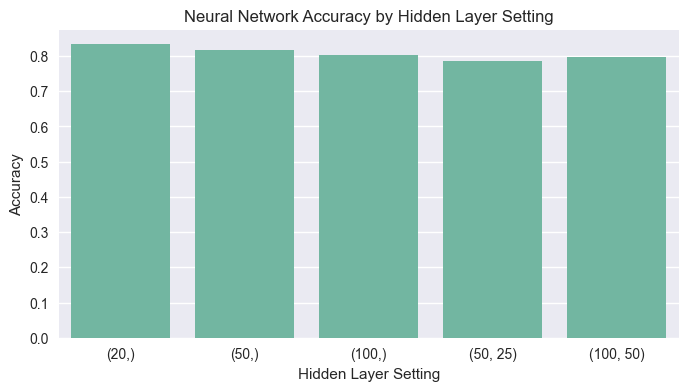

In [14]:
# plotting architecture comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=nn_results_df, x="architecture", y="accuracy")
plt.title("Neural Network Accuracy by Hidden Layer Setting")
plt.xlabel("Hidden Layer Setting")
plt.ylabel("Accuracy")
plt.show()

In [15]:
# selecting the best architecture
best_architecture = nn_results_df.loc[nn_results_df["accuracy"].idxmax(), "architecture"]
print("Best architecture:", best_architecture)

Best architecture: (20,)


In [16]:
# converting the selected architecture back into a tuple
best_architecture_tuple = eval(best_architecture)

# training the final model
final_nn = MLPClassifier(
    hidden_layer_sizes=best_architecture_tuple,
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

final_nn.fit(X_train_scaled, y_train)

final_preds = final_nn.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, final_preds))

Final Accuracy: 0.833125


In [17]:
# final classification report
print(classification_report(y_test, final_preds, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

        High       0.72      0.60      0.65       151
         Low       0.83      0.83      0.83       508
      Medium       0.85      0.87      0.86       941

    accuracy                           0.83      1600
   macro avg       0.80      0.77      0.78      1600
weighted avg       0.83      0.83      0.83      1600



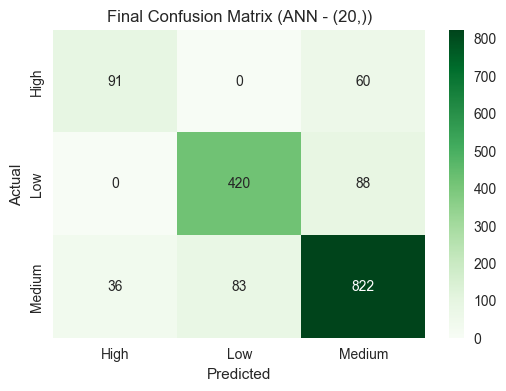

In [18]:
# final confusion matrix
final_cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title(f"Final Confusion Matrix (ANN - {best_architecture})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

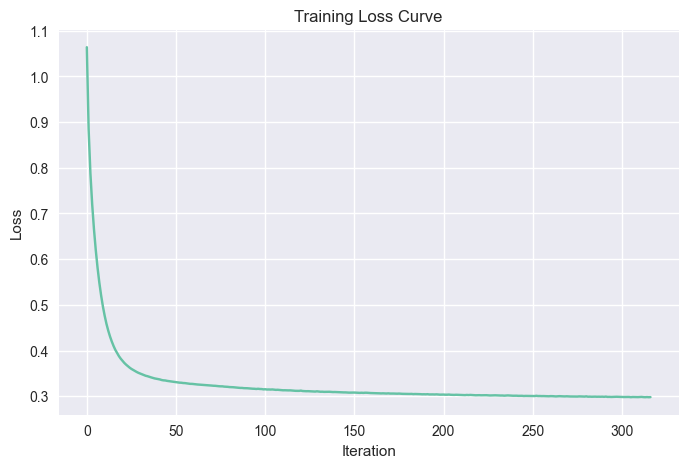

In [19]:
# looking at the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(final_nn.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## 9. Conclusion

In this notebook I implemented an Artificial Neural Network (ANN) using a dataset about AI and student performance.

### Summary of work completed
- loaded and explored the dataset
- checked and fixed missing values in categorical columns
- selected `performance_category` as the target variable
- removed `student_id`, `final_score`, and `passed` from the features
- encoded categorical columns using `LabelEncoder`
- split the data into training and test sets
- scaled the features using `StandardScaler`
- trained an initial neural network model
- evaluated the model using accuracy, classification report, and confusion matrix
- compared several hidden layer settings
- selected the best-performing network structure
- trained and evaluated the final model
- plotted the training loss curve

### Results
The first neural network model with `hidden_layer_sizes=(50,)` achieved an accuracy of **0.8169**.

After comparing different hidden layer settings, the best result came from the architecture **(20,)**, which achieved a final accuracy of **0.8331**.

The final model performed best on the `Medium` and `Low` classes, while the `High` class was more difficult to classify correctly. This is similar to the pattern seen in the other notebooks and is likely affected by the class imbalance in the dataset.

The training loss curve showed that the loss decreased steadily, which suggests the model was learning useful patterns, even though some runs produced a convergence warning at 500 iterations.

### Reflection
This notebook showed that an Artificial Neural Network can perform well on this dataset and can compete with other supervised learning methods such as k-NN and SVM.

It also showed that bigger or deeper networks do not automatically give better performance. In this case, the smaller network `(20,)` performed better than the larger architectures tested.
